# Figure 1C–H

Cell-state structure of the screened dendritic-cell population: clustering,
cluster marker genes, cell cycle phase, and the DC1 / DC2 / mregDC /
macrophage signature scores.

Panels are written to `figures/` by scanpy under the names used in the
manuscript.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats

sc.set_figure_params(dpi=100, fontsize=12)
sc.settings.verbosity = "hint"
sc.settings.figdir = Path("figures")      # where sc.pl(..., save=) writes
sc.settings.figdir.mkdir(exist_ok=True)

In [2]:
E3LIGASE = Path("/home/eraslab1/Projects/E3Ligase/analysisSingle")

SCREEN_H5AD    = E3LIGASE / "outputs/anndata/OriginalFiles/adata-hash-features_singlets_05242020.h5ad"
DC_STATE_GENES = E3LIGASE / "TextFiles/PositiveControls/DC_cellstate_genes.csv"
CELL_CYCLE_GENES = Path("regev_lab_cell_cycle_genes.txt")

# leiden cluster -> cell state; every other cluster is DC2
SUBCELL_TYPE_BY_CLUSTER = {"8": "DC1", "5": "mReg", "3": "Mac"}

N_RANK_GENES           = 2000   # genes ranked per cluster
N_MARKERS_PER_CLUSTER  = 8      # top markers shown in the dot plot

## Load the screen and label cell states

In [3]:
adata = sc.read(SCREEN_H5AD)

adata.obs["subcellType"] = "DC2"
for cluster, label in SUBCELL_TYPE_BY_CLUSTER.items():
    adata.obs.loc[adata.obs["leiden"] == cluster, "subcellType"] = label

adata.obs["subcellType"].value_counts()

/home/eraslab1/miniconda3/lib/python3.8/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/eraslab1/miniconda3/lib/python3.8/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


DC2     428550
Mac      71211
mReg     13839
DC1       5935
Name: subcellType, dtype: int64

## Clusters and their relationships — Figure 1C, Supp. 1F

In [4]:
f, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(
    adata, color="leiden", save="Figure_1C.pdf", legend_fontoutline=3,
    legend_fontsize=14, legend_fontweight="normal", title="Clusters",
    ax=ax, show=False, size=0.3,
);

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


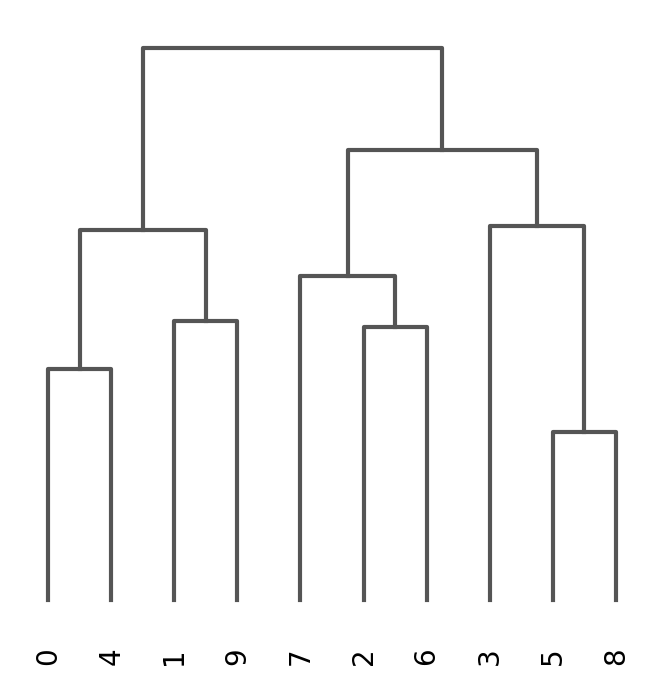

<AxesSubplot:>

In [5]:
sc.tl.dendrogram(adata, groupby="leiden")
sc.pl.dendrogram(adata, groupby="leiden", save="SupFig_1F.pdf")

## Cluster marker genes — Supp. 1G

The top markers of each cluster, kept in cluster order.

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:02:38)


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/eras

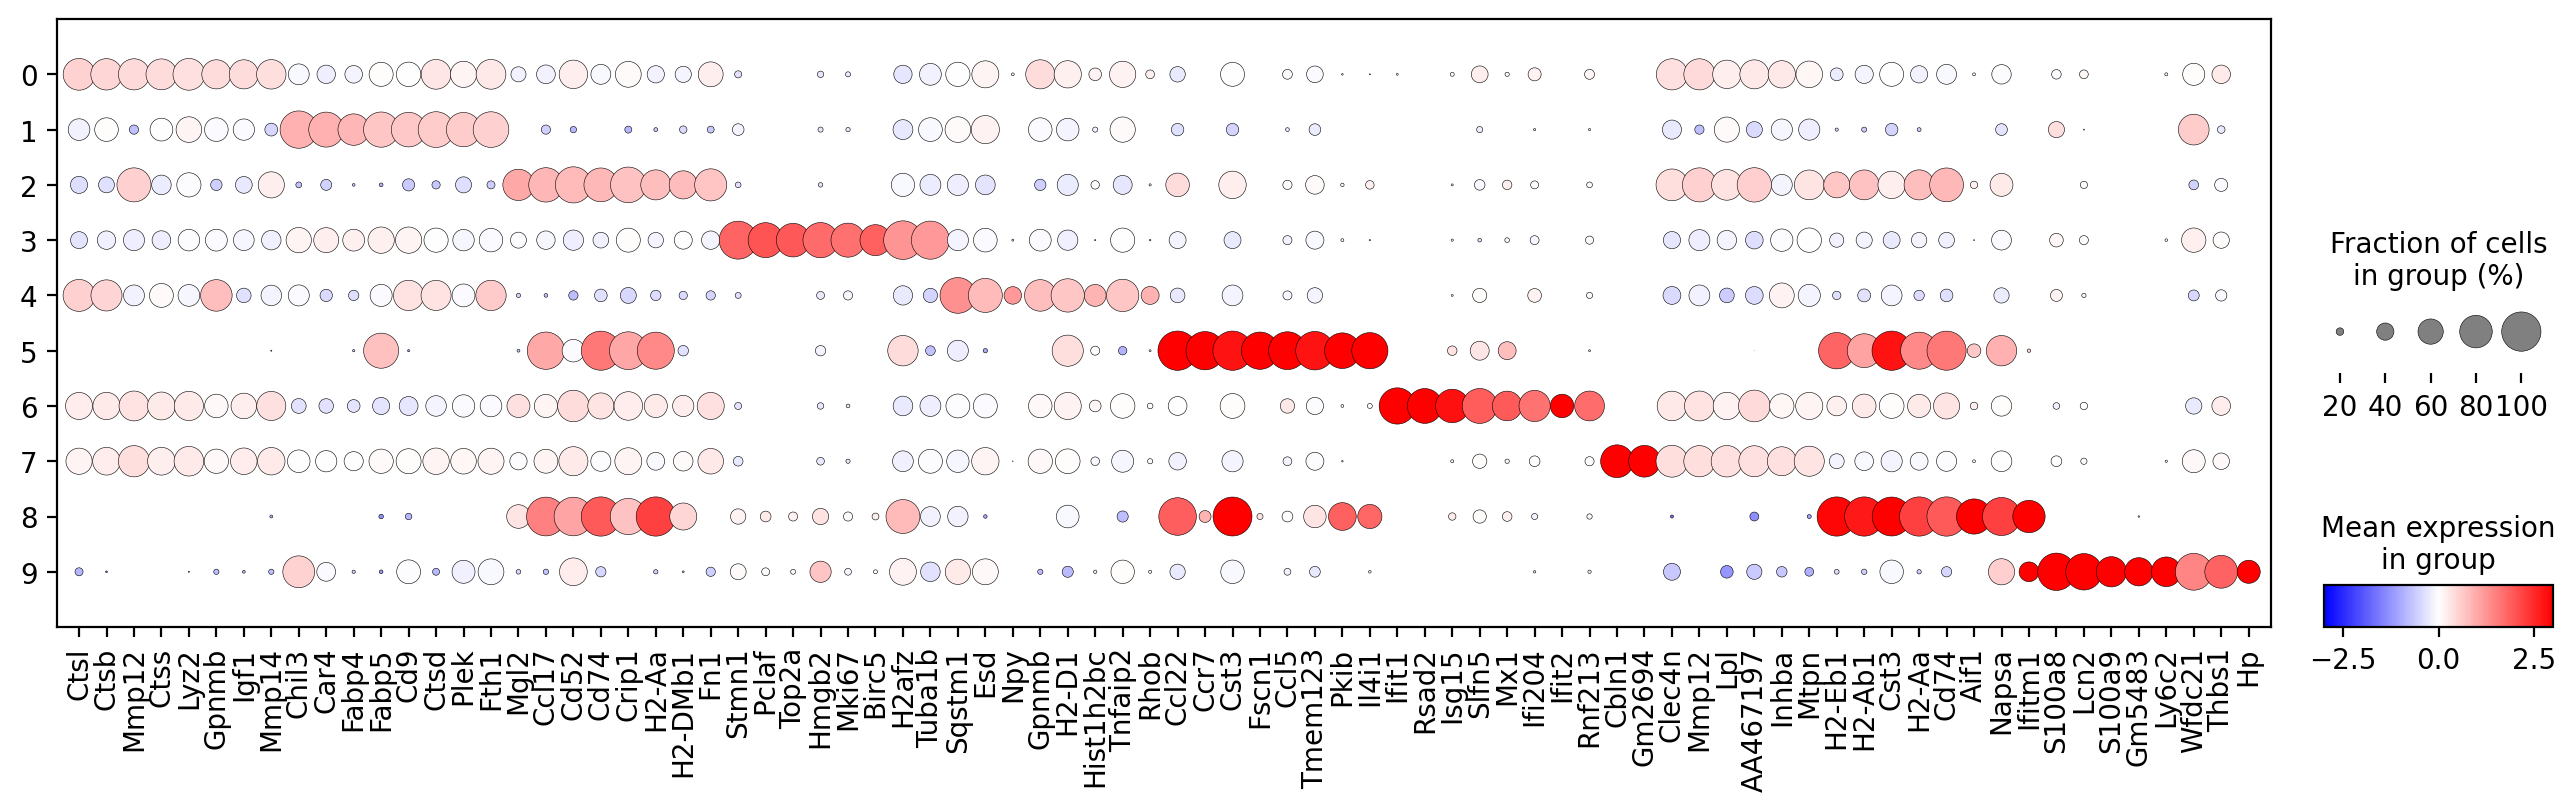

In [6]:
sc.tl.rank_genes_groups(
    adata, groupby="leiden", n_genes=N_RANK_GENES,
    method="t-test_overestim_var", use_raw=False,
)

markerGenes = (
    pd.DataFrame(adata.uns["rank_genes_groups"]["names"])
    .iloc[:N_MARKERS_PER_CLUSTER, :]
    .values.flatten(order="F")          # column-major: cluster by cluster
)

sc.pl.dotplot(
    adata, markerGenes, groupby="leiden", cmap="bwr", figsize=(16, 4),
    vmin=-3, vmax=3, use_raw=False, dot_min=0.1, dot_max=1, save="SupFig_1G.pdf",
)

## Cell cycle phase — Figure 1G

The Regev-lab list is the standard 97 genes of Tirosh et al. 2015, S phase
first. It is kept beside this notebook because its original URL no longer
resolves. Gene symbols are capitalised for mouse.

calculating cell cycle phase
computing score 'S_score'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'S_score', score of gene set (adata.obs).
    643 total control genes are used. (0:00:10)
computing score 'G2M_score'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'G2M_score', score of gene set (adata.obs).
    683 total control genes are used. (0:00:09)
-->     'phase', cell cycle phase (adata.obs)


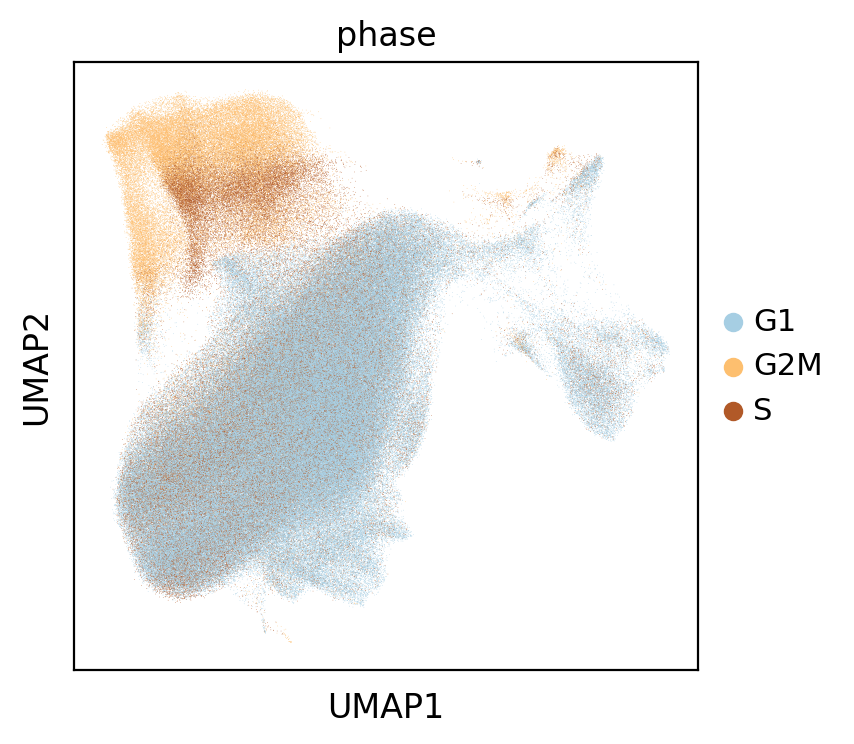

In [7]:
cell_cycle_genes = [line.strip().capitalize() for line in CELL_CYCLE_GENES.read_text().splitlines()]
s_genes, g2m_genes = cell_cycle_genes[:43], cell_cycle_genes[43:]

sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)
sc.pl.umap(adata, color="phase", palette="Paired", save="Figure_1G.pdf")

## Quality metrics per cluster

A check that no cluster is driven by depth or by dying cells.

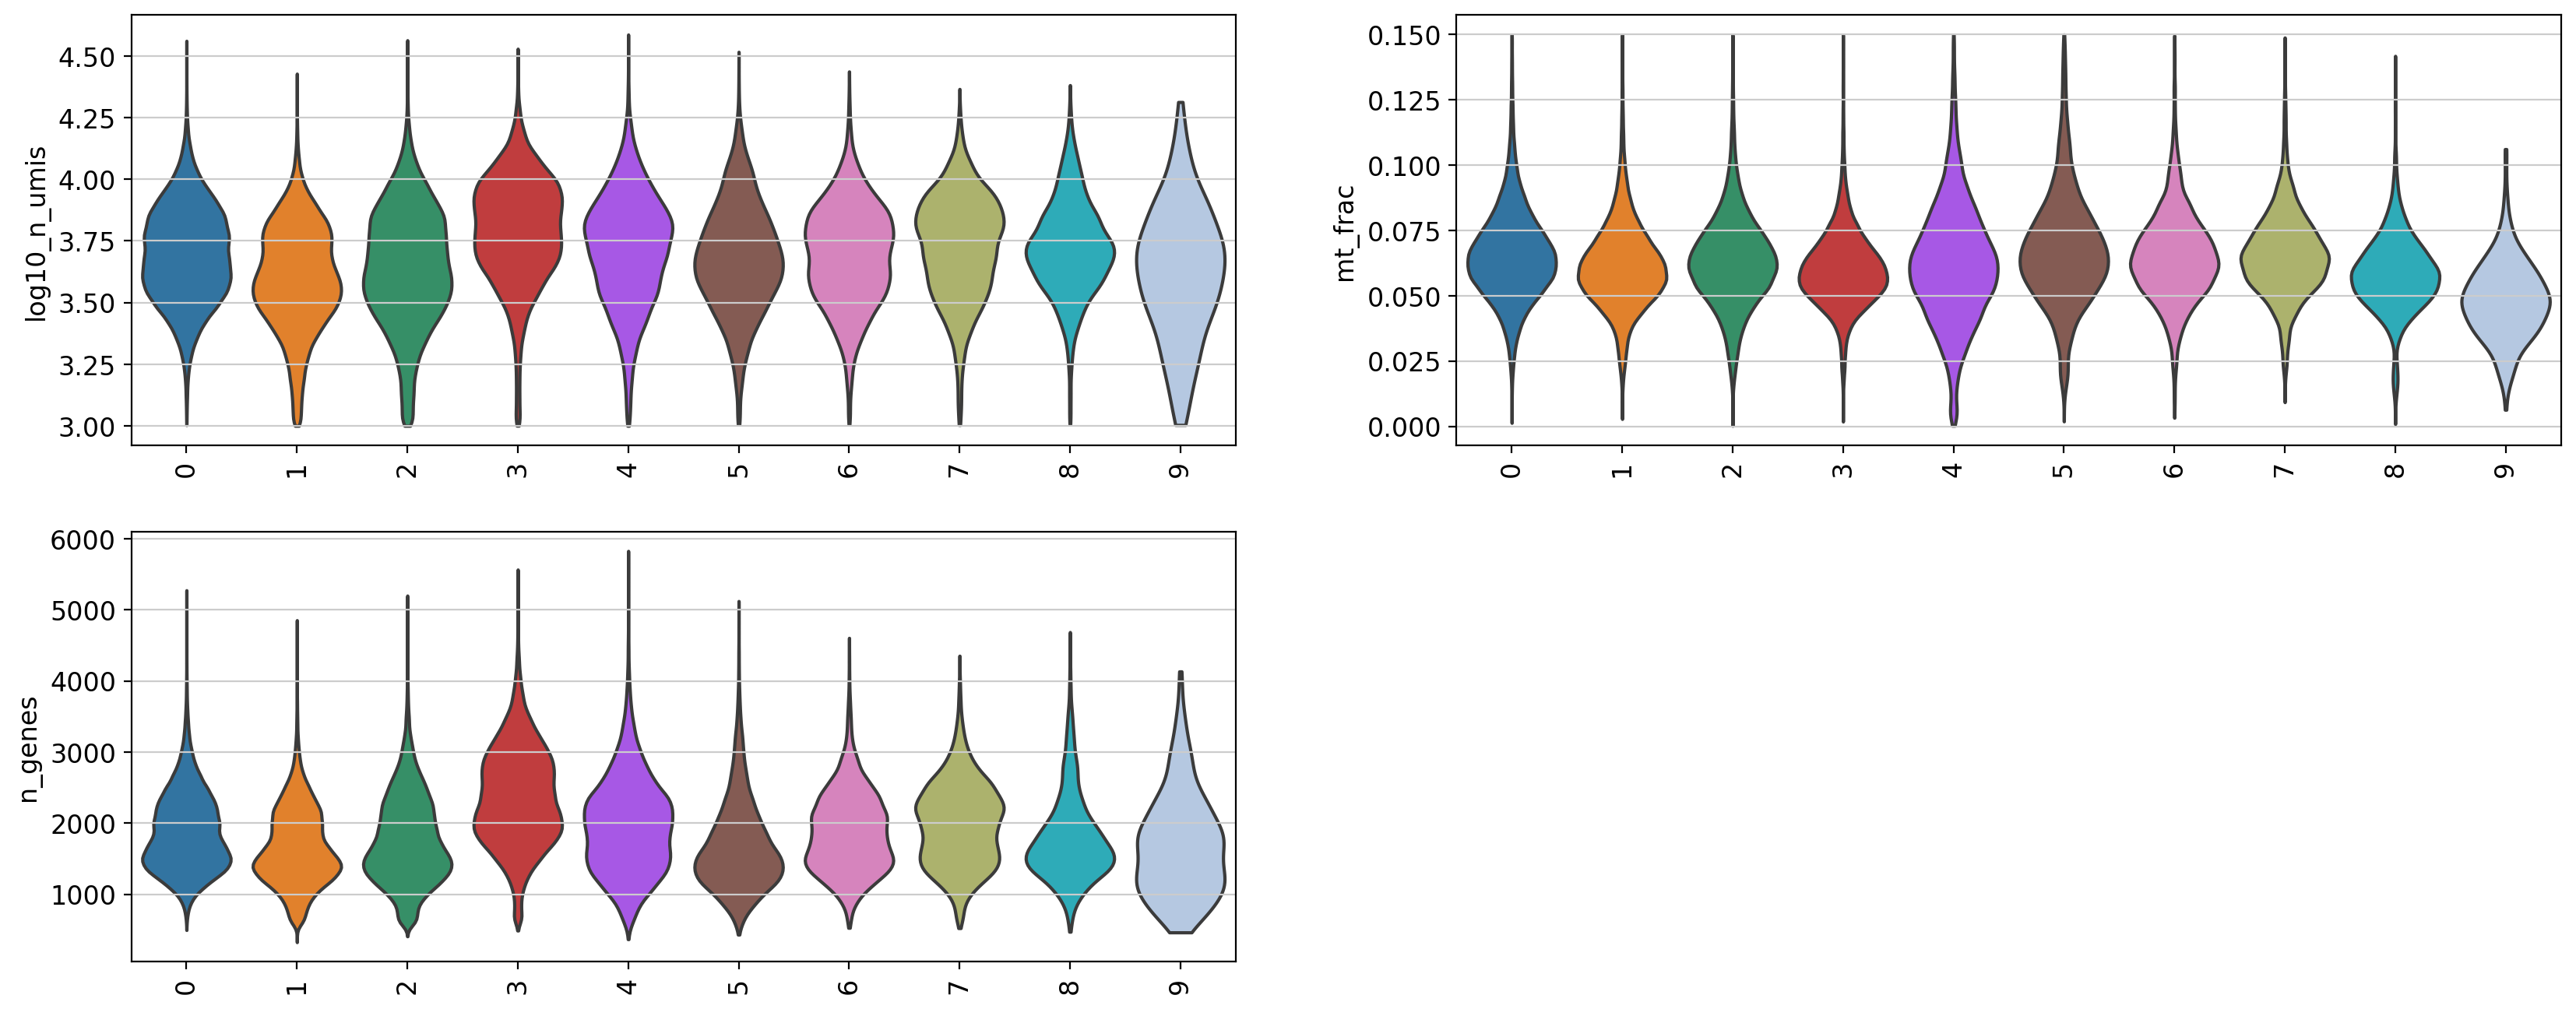

In [8]:
f, ax = plt.subplots(2, 2, figsize=(20, 8))
for axis, key in zip([ax[0][0], ax[0][1], ax[1][0]], ["log10_n_umis", "mt_frac", "n_genes"]):
    sc.pl.violin(
        adata, keys=key, groupby="leiden", rotation=90,
        ax=axis, show=False, stripplot=False,
    )
ax[1][1].set_visible(False)      # only three metrics to show

## Cell-state signature scores — Figure 1D, 1E, 1F and Supp. 1X, 1Y

Each state is scored from its marker set and shown on the UMAP. Colour limits
differ between signatures because their score ranges differ.

computing score 'DC1'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'DC1', score of gene set (adata.obs).
    1192 total control genes are used. (0:00:12)


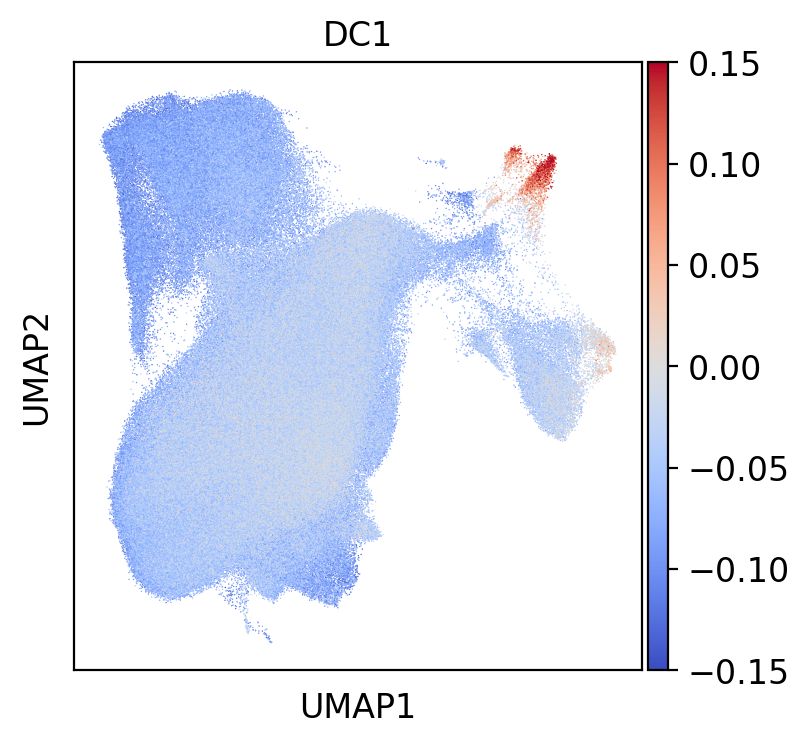

computing score 'DC2'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'DC2', score of gene set (adata.obs).
    1179 total control genes are used. (0:00:11)


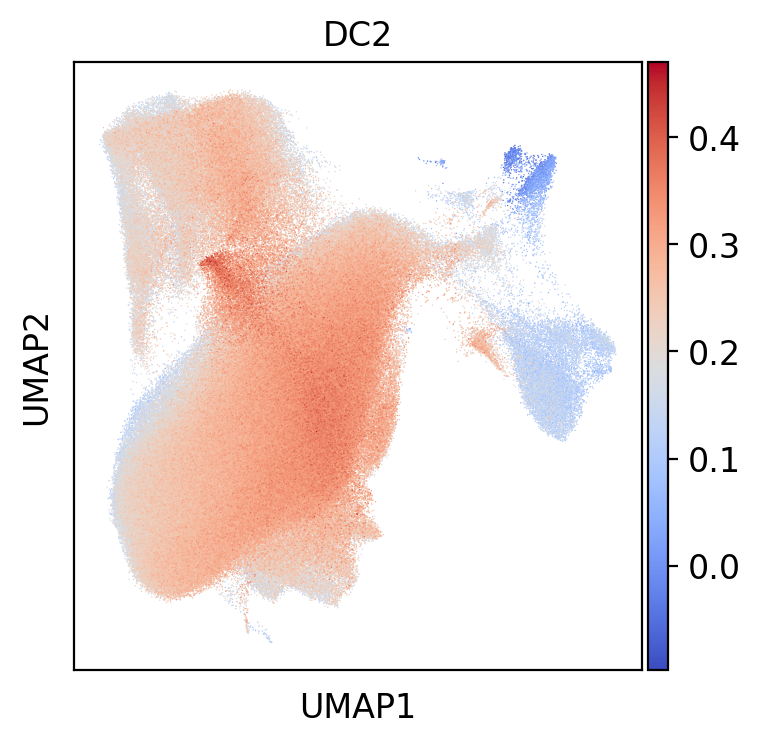

computing score 'mreg'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'mreg', score of gene set (adata.obs).
    1170 total control genes are used. (0:00:12)


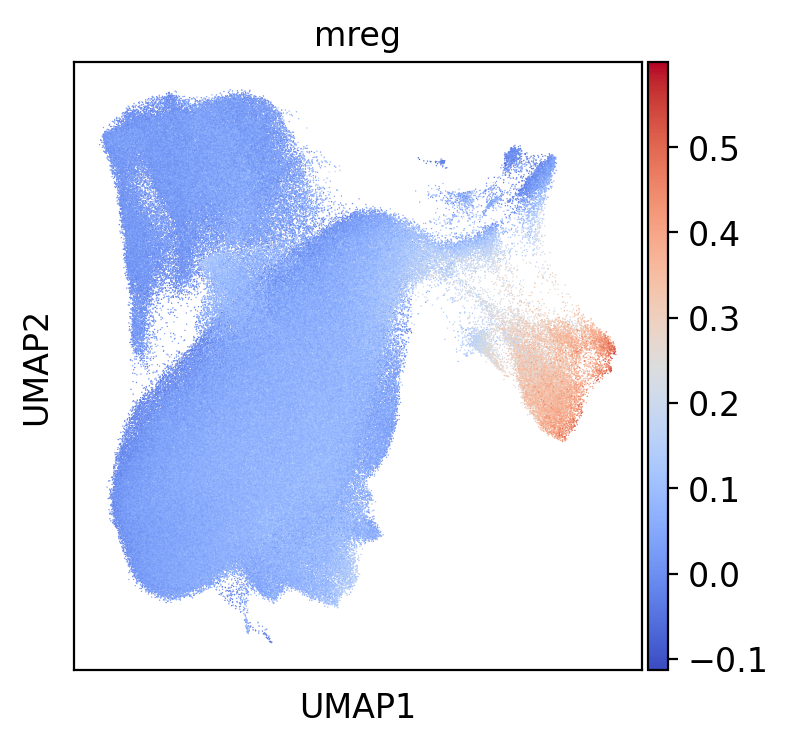

computing score 'Mac'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'Mac', score of gene set (adata.obs).
    1126 total control genes are used. (0:00:12)


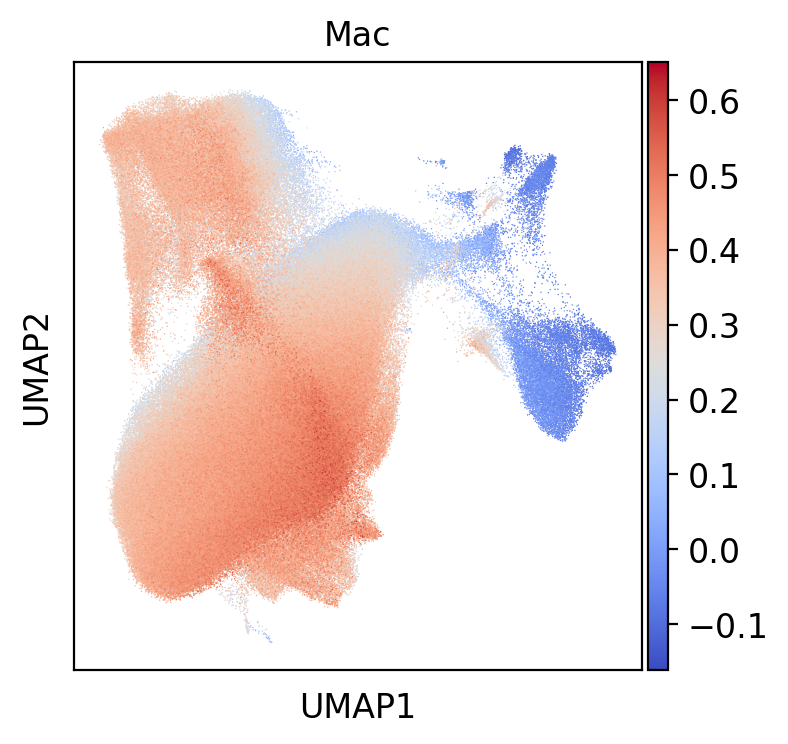

In [9]:
dcGenes = pd.read_csv(DC_STATE_GENES)

# score name -> (column in DC_STATE_GENES, panel file, extra umap arguments)
SIGNATURES = {
    "DC1":  ("DC1 genes",        "Figure_1F.pdf", dict(vmin=-0.15, vmax=0.15)),
    "DC2":  ("DC2 genes",        "Figure_1D.pdf", {}),
    "mreg": ("mregDC genes",     "Figure_1E.pdf", {}),
    "Mac":  ("Macrophage genes", "SupFig_1Y.pdf", {}),
}

signature_genes = {}
for score_name, (column, panel, umap_kwargs) in SIGNATURES.items():
    genes = dcGenes[column].unique()
    signature_genes[score_name] = genes
    sc.tl.score_genes(adata=adata, gene_list=genes, score_name=score_name)
    sc.pl.umap(
        adata, color=score_name, size=1, color_map="coolwarm",
        save=panel, **umap_kwargs,
    )

A combined dendritic-cell signature, and its contrast with the macrophage score.

computing score 'DCSig'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'DCSig', score of gene set (adata.obs).
    1122 total control genes are used. (0:00:13)


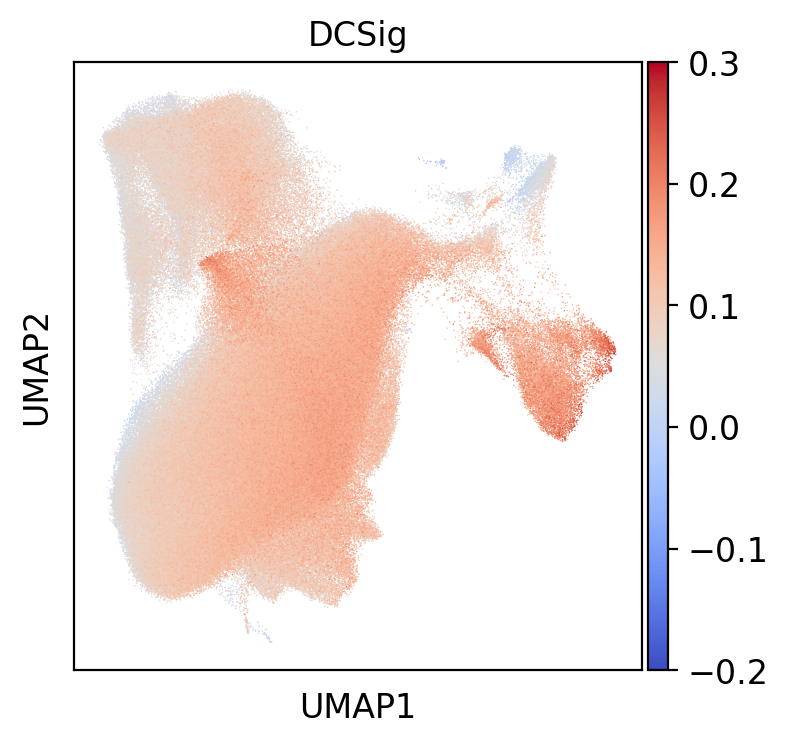

In [10]:
allDCgenes = np.concatenate(
    [signature_genes["DC1"], signature_genes["DC2"], signature_genes["mreg"]]
)
sc.tl.score_genes(adata=adata, gene_list=allDCgenes, score_name="DCSig")
sc.pl.umap(
    adata, color="DCSig", size=1, color_map="coolwarm",
    vmin=-0.2, vmax=0.3, save="SupFig_1X.pdf",
)

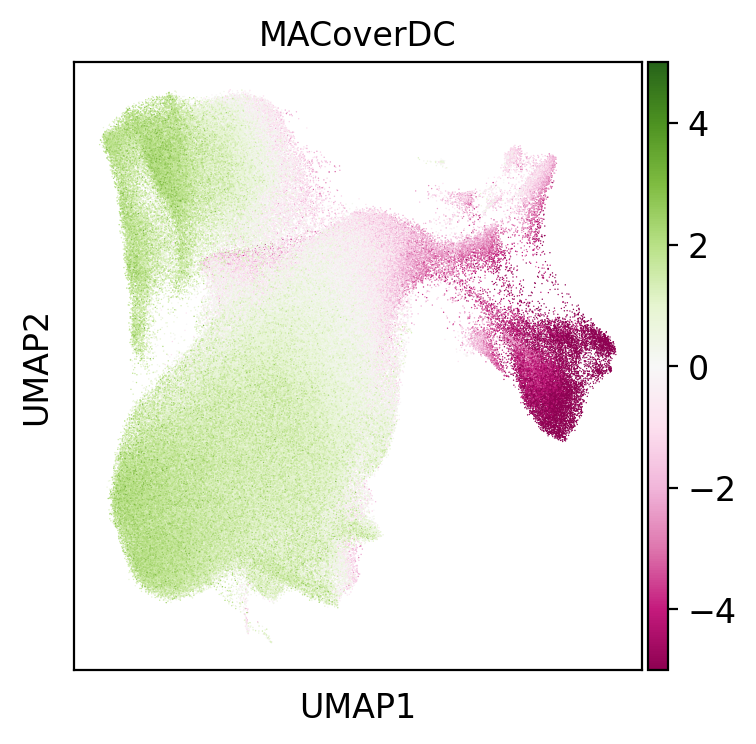

In [11]:
adata.obs["DCSig_zscore"] = scipy.stats.zscore(adata.obs["DCSig"])
adata.obs["Mac_zscore"] = scipy.stats.zscore(adata.obs["Mac"])
adata.obs["MACoverDC"] = adata.obs["Mac_zscore"] - adata.obs["DCSig_zscore"]

# NOTE: saved as Figure_2F.pdf in the original notebook; name kept unchanged.
sc.pl.umap(
    adata, color="MACoverDC", size=1, color_map="PiYG",
    vmin=-5, vmax=5, save="Figure_2F.pdf",
)